### Análisis de datos II
# Clase 1 - Interpretabilidad global

### Problemas de regresión

Vamos a trabajar con el dataset de Penguins y un problema de regresión, que consiste en predecir el peso del pingüino a partir de sus medidas corporales.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence

from alibi.explainers import ALE
from alibi.explainers import plot_ale

/Users/ari/Desktop/github_repos/CEIA_Analisis_de_datos_II/.venv/lib/python3.12/site-packages/alibi/explainers/shap_wrappers.py:312: SyntaxWarning: invalid escape sequence '\p'
  importance values to the model output. Since the feature importance values, :math:`\phi`, sum up to the
/Users/ari/Desktop/github_repos/CEIA_Analisis_de_datos_II/.venv/lib/python3.12/site-packages/alibi/explainers/shap_wrappers.py:1066: SyntaxWarning: invalid escape sequence '\i'
  :math:`y \in \{0, 1\}`. Currently only binary cross-entropy and squared error losses can be explained. \


## Dataset

In [2]:
# Dataset
penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


**Inspección rápida de la correlación entre variables numéricas**

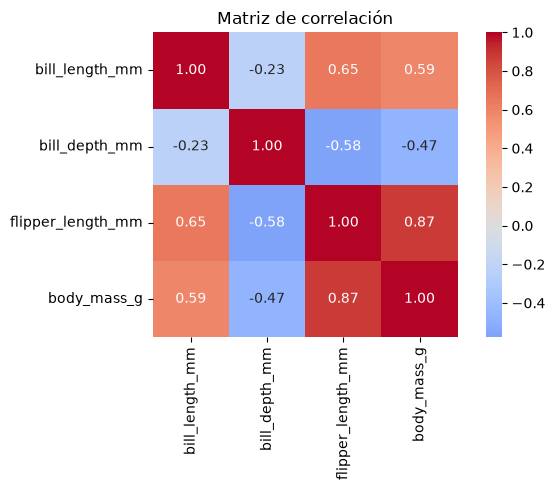

In [3]:
data = penguins.copy()
corr = data.corr(numeric_only=True)

plt.figure(figsize=(7, 5))

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Entrenamos un Random Forest para predecir body_mass_g (regresión)

In [4]:
# Variables predictoras y target
target = "body_mass_g"

X = penguins.drop(columns=target)
y = penguins[target]

# Columnas categóricas y numéricas
categorical_features = ["species", "island", "sex"]
numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]

In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
    
# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

**Para que los gráficos sean más legibles, "limpiamos" los nombres de las features transformadas.**

In [6]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['cat__species_Adelie', 'cat__species_Chinstrap',
       'cat__species_Gentoo', 'cat__island_Biscoe', 'cat__island_Dream',
       'cat__island_Torgersen', 'cat__sex_Female', 'cat__sex_Male',
       'num__bill_length_mm', 'num__bill_depth_mm',
       'num__flipper_length_mm'], dtype=object)

In [7]:
feature_names_clean = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor.get_feature_names_out()
]
feature_names_clean

['species_Adelie',
 'species_Chinstrap',
 'species_Gentoo',
 'island_Biscoe',
 'island_Dream',
 'island_Torgersen',
 'sex_Female',
 'sex_Male',
 'bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm']

In [8]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train_trans, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [9]:
# Predicciones
y_pred = model.predict(X_test_trans)

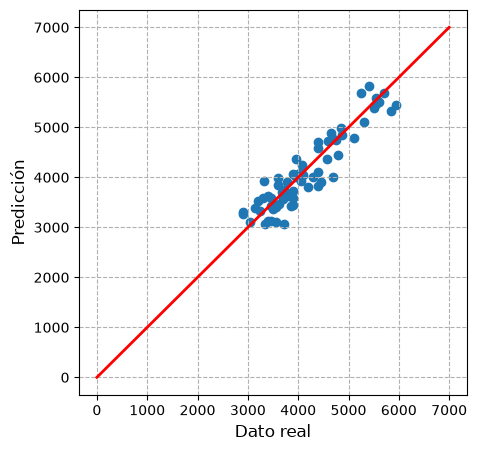

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(5, 5))

plt.scatter(y_test,y_pred)
plt.grid(True, ls='--')
plt.plot([0, 7000], [0, 7000], color='r', linestyle='-', linewidth=2)

plt.ylabel('Predicción',size=12)
plt.xlabel('Dato real',size=12)
plt.show()

**Calculamos algunas métricas para ver cómo anduvo el modelo.**

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"MAE (Error Absoluto Medio): {mae:.3f}")

R²: 0.860
MAE (Error Absoluto Medio): 240.649


---
### Permutation Feature Importance (PFI)

Con PFI identificamos qué variables son globalmente críticas.

La permutación ocurre sobre las variables originales, no las transformadas.

In [12]:
model_pfi = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

Vemos cómo calcular PFI manualmente sobre la varible flipper_length_mm.

In [13]:
X_test_perm = X_test.copy()

X_test_perm["flipper_length_mm"] = X_test_perm["flipper_length_mm"].sample(
    frac=1,
    random_state=42
).values

y_pred_perm = model_pfi.predict(X_test_perm)

r2_perm = r2_score(y_test, y_pred_perm)
print(f"R² antes: {r2:.3f}. R²  después de permutar flipper_length_mm: {r2_perm:.3f} => Pérdida: {r2 - r2_perm:.3f}")

R² antes: 0.860. R²  después de permutar flipper_length_mm: 0.692 => Pérdida: 0.168


Al "destruir" la información de flipper_length_mm, el R² cayó 0.1682. Por lo tanto, esa variable aporta información importante para las predicciones.
Miremos otra métrica: MAE (Mean absolute error).

In [14]:
mae_perm = mean_absolute_error(y_test, y_pred_perm)
print(f"MAE antes: {mae:.2f}. MAE después de permutar flipper_length_mm: {mae_perm:.3f} => Aumento del error: {mae_perm - mae:.2f}")

MAE antes: 240.65. MAE después de permutar flipper_length_mm: 348.164 => Aumento del error: 107.51


Para MAE la lógica es inversa. Al permutar la variable, el error absoluto medio aumentó en 107.51.

---
Ahora calculamos PFI para todas las features.

In [15]:
result = permutation_importance(
    model_pfi,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42
)

In [16]:
pfi = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

pfi = pfi.sort_values("importance", ascending=False)
pfi

,feature,importance,std
0,species,0.702452,0.094691
5,sex,0.167503,0.030694
4,flipper_length_mm,0.124679,0.020088
3,bill_depth_mm,0.017872,0.013833
2,bill_length_mm,0.006022,0.006952
1,island,-0.007448,0.007481


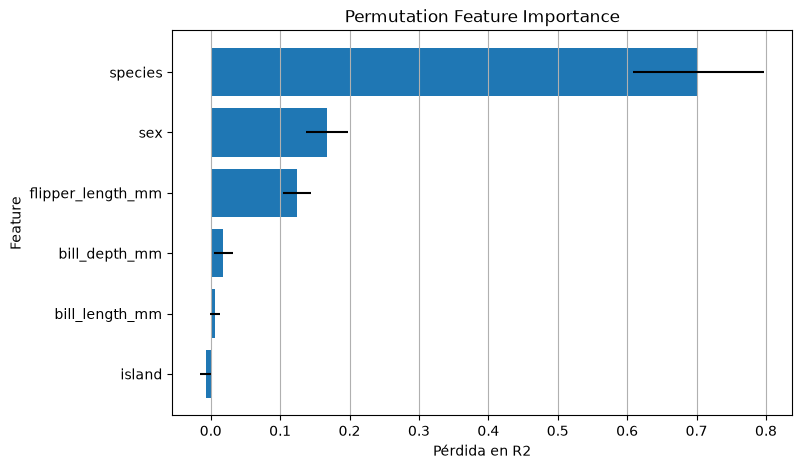

In [17]:
plt.figure(figsize=(8, 5))

plt.barh(
    pfi["feature"],
    pfi["importance"],
    xerr=pfi["std"]
)

plt.xlabel("Pérdida en R2")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.show()

---
### PDP (*Partial Dependence Plots*) - ICE plots

El PDP muestra el efecto marginal que 1 o 2 features tienen sobre la predicción promedio de un modelo de ML.

Responde a la pregunta:
¿Cómo cambia la predicción del modelo al modificar el valor de una feature mientras el resto permanece fijo?

#### Partial Dependence Plot con respecto a la longitud del pico

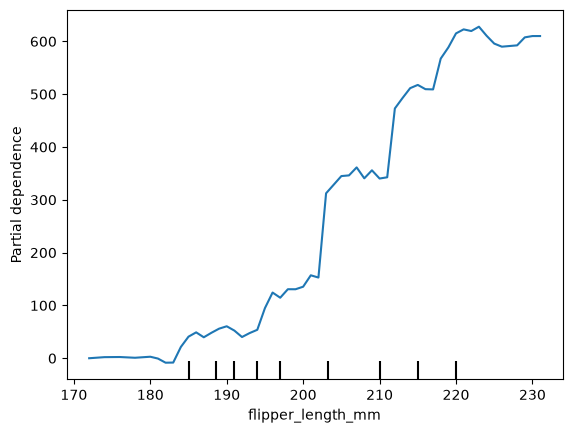

In [18]:
features=["flipper_length_mm"]
PartialDependenceDisplay.from_estimator(
    model,
    X_train_trans,
    features=features,
    feature_names=feature_names_clean,
    centered=True
)
plt.show()

En el eje horizontal vemos los distintos valores de la feature.

En el eje vertical vemos, para cada valor v, la predicción promedio del modelo cuando esa feature toma el valor v para cada una de las observaciones.

### ICE plot

Genera una curva para cada observación.

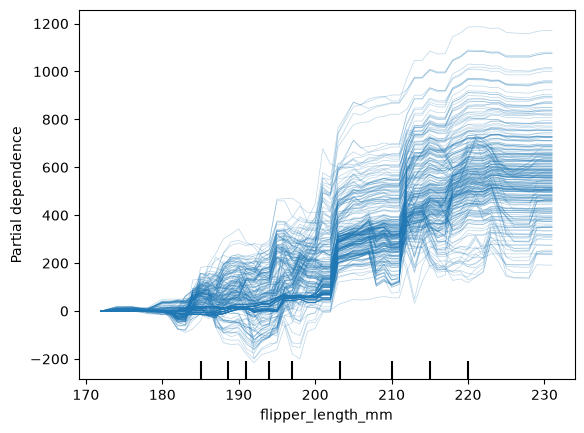

In [19]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train_trans,
    features=["flipper_length_mm"],
    feature_names=feature_names_clean,
    kind="individual",
    centered=True,
)
plt.show()

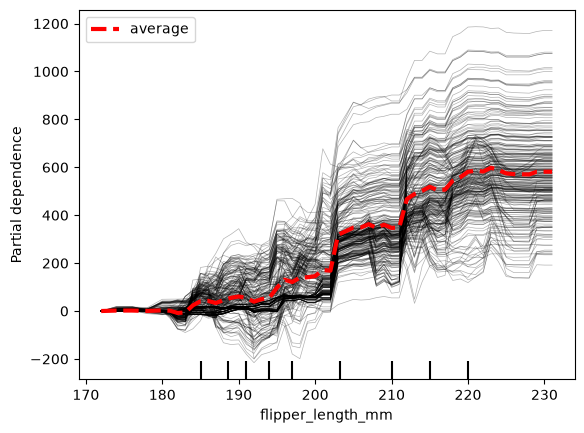

In [20]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train_trans,
    features=["flipper_length_mm"],
    feature_names=feature_names_clean,
    kind='both',
    centered= True,
    ice_lines_kw={"color": "black"},
    pd_line_kw={"color": "red","lw":3,'linestyle':'--'})
plt.show()

### Contour plot

Un PDP bidimensional muestra cómo cambia la predicción promedio del modelo al variar simultáneamente dos features.

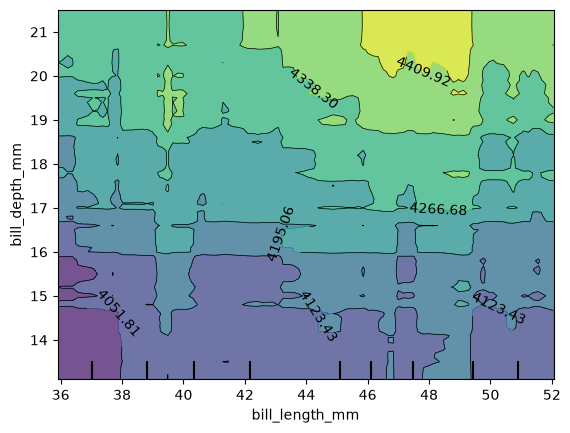

In [21]:
features=[("bill_length_mm", "bill_depth_mm")]
PartialDependenceDisplay.from_estimator(
    model,
    X_train_trans,
    features=features,
    feature_names=feature_names_clean)
plt.show()

Cómo leemos el plot:

- Color / curvas de nivel: es el nivel de body_mass_g (target) predicho por el modelo.
- Los números sobre las curvas son las predicciones promedio del modelo en esas regiones.

Por ejemplo, en el área inferior izquierda, para combinaciones de bill_length_mm y bill_depth_mm cercanas a esa región, la predicción promedio está alrededor de 4052 g.

Las áreas nos muestran que el efecto no es independiente para las dos variables, hay una interacción entre ellas. Por ejemplo, alrededor de bill_depth_mm ≈ 20 mm:
- con bill_length_mm ≈ 36–38, la predicción está cerca de 4267 g;
- con bill_length_mm ≈ 43–44, ronda 4338 g;
- con bill_length_mm ≈ 47–49, llega aproximadamente a 4410 g.

**Alerta!**

En PDP, algunas zonas del gráfico pueden corresponder a combinaciones de bill_length y bill_depth que tienen poca o ninguna representación real en los datos.

---
### ALE

El ALE responde:

¿Cómo cambia la predicción considerando los cambios locales observados en los datos?

In [22]:
# Inicializamos el explainer de ALE
ale = ALE(
    predictor=model.predict,
    feature_names=feature_names,
    target_names=["body_mass_g"]
)

exp = ale.explain(X_train_trans)

### ALE explanations
ALE está pensado principalmente para variables continuas.

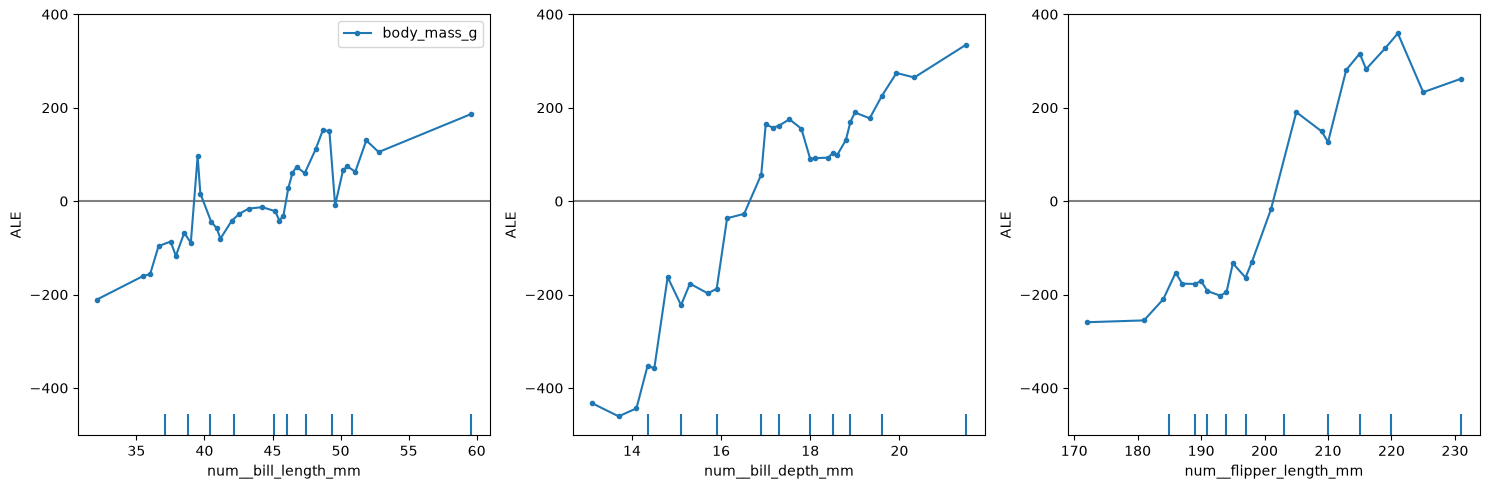

In [23]:
# Plot ALE explanation para las features numéricas
plot_ale(exp, features=[8,9,10], fig_kw={'figwidth':15, 'figheight': 5})
plt.show()

#### Interpretación del ALE plot
- los intervalos en x son de longitud variable. Esto es porque por defecto el algoritmo selecciona intervalos que incluyan al menos 4 observaciones.
- el valor de ALE (accumulated local effects) está centrado en cero. Esto se logra restando el promedio del ALE no centrado de cada ALE no centrado. Esto se puede interpretar así: por ejemplo, un depth de 17 mm incrementa el número predicho de body_mass_g (target) en aprox. 200 comparado con la predicción promedio.

#### Conclusiones:
- El largo del pico (bill_length_mm) tiene un efecto moderado en la predicción.
- El ancho del pico y la longitud de la aleta tienen una fuerte incidencia en la predicción de body_mass_g.